# 🛒 Shopper Spectrum: Customer Segmentation & Product Recommendations
## Labmentix Internship Project | E-Commerce Analytics
---
**Domain:** E-Commerce & Retail Analytics  
**Tech Stack:** Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn  
**Objective:** RFM-based customer segmentation + collaborative filtering product recommendation


## 📦 Step 0 — Import Libraries

In [1]:
# ── Standard Libraries ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Scikit-learn ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# ── Plot Styling ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5),
                     "axes.titlesize": 14, "axes.labelsize": 12})
PALETTE = ["#e63946","#457b9d","#2a9d8f","#e9c46a","#264653"]

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 📂 Step 1 — Dataset Collection & Understanding

**Dataset:** UCI Online Retail (2022–2023 transactions)  
**Source:** [Link to dataset](https://archive.ics.uci.edu/dataset/352/online+retail)


In [2]:
# ── Load the dataset ──────────────────────────────────────────
df_raw = pd.read_csv("online_retail.csv", encoding="latin-1", parse_dates=["InvoiceDate"])

print(f"📊 Dataset Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"📅 Date Range     : {df_raw['InvoiceDate'].min().date()} → {df_raw['InvoiceDate'].max().date()}")
print()
df_raw.head()


📊 Dataset Shape  : 541,909 rows × 8 columns
📅 Date Range     : 2022-12-01 → 2023-12-09



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# ── Data Types & Memory ───────────────────────────────────────
print("=== Column Info ===")
df_raw.info()


=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
# ── Basic Statistics ──────────────────────────────────────────
df_raw.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2023-07-04 13:34:57.156387072,2022-12-01 08:26:00,2023-03-28 11:34:00,2023-07-19 17:17:00,2023-10-19 11:27:00,2023-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ── Missing Values ────────────────────────────────────────────
missing = df_raw.isnull().sum().rename("Missing Count")
missing_pct = (df_raw.isnull().mean() * 100).round(2).rename("Missing %")
print(pd.concat([missing, missing_pct], axis=1).to_string())


             Missing Count  Missing %
InvoiceNo                0       0.00
StockCode                0       0.00
Description           1454       0.27
Quantity                 0       0.00
InvoiceDate              0       0.00
UnitPrice                0       0.00
CustomerID          135080      24.93
Country                  0       0.00


In [6]:
# ── Duplicate Rows ────────────────────────────────────────────
print(f"Duplicate rows : {df_raw.duplicated().sum():,}")


Duplicate rows : 5,268


In [7]:
# ── Unique Value Counts per Column ────────────────────────────
print("Unique values per column:")
for col in df_raw.columns:
    print(f"  {col:<15}: {df_raw[col].nunique():>6,}")


Unique values per column:
  InvoiceNo      : 25,900
  StockCode      :  4,070
  Description    :  4,223
  Quantity       :    722
  InvoiceDate    : 23,260
  UnitPrice      :  1,630
  CustomerID     :  4,372
  Country        :     38


In [8]:
# ── Sample Cancelled Invoices ────────────────────────────────
print("Cancelled invoices (InvoiceNo starts with C):")
cancelled_mask = df_raw["InvoiceNo"].astype(str).str.startswith("C")
print(f"  Count : {cancelled_mask.sum():,}")
df_raw[cancelled_mask].head(3)


Cancelled invoices (InvoiceNo starts with C):
  Count : 9,288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom


---
## 🧹 Step 2 — Data Preprocessing


In [9]:
# ── 2.1  Remove rows with missing CustomerID ──────────────────
df = df_raw.copy()
before = len(df)
df.dropna(subset=["CustomerID"], inplace=True)
print(f"Removed {before - len(df):,} rows with missing CustomerID")
print(f"Remaining rows : {len(df):,}")


Removed 135,080 rows with missing CustomerID
Remaining rows : 406,829


In [10]:
# ── 2.2  Remove cancelled invoices ────────────────────────────
before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Removed {before - len(df):,} cancelled invoices")
print(f"Remaining rows : {len(df):,}")


Removed 8,905 cancelled invoices
Remaining rows : 397,924


In [11]:
# ── 2.3  Remove negative / zero Quantity and UnitPrice ────────
before = len(df)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print(f"Removed {before - len(df):,} rows with non-positive Quantity or UnitPrice")
print(f"Remaining rows : {len(df):,}")


Removed 40 rows with non-positive Quantity or UnitPrice
Remaining rows : 397,884


In [12]:
# ── 2.4  Drop duplicates ──────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df):,} duplicate rows")
print(f"Final clean rows : {len(df):,}")


Removed 5,192 duplicate rows
Final clean rows : 392,692


In [13]:
# ── 2.5  Ensure correct dtypes ────────────────────────────────
df["CustomerID"] = df["CustomerID"].astype(str).str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Derived column: TotalPrice per line item
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("✅ Preprocessing complete!")
df.head()


✅ Preprocessing complete!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
# ── 2.6  Post-cleaning Summary ────────────────────────────────
print(f"Unique Customers : {df['CustomerID'].nunique():,}")
print(f"Unique Products  : {df['Description'].nunique():,}")
print(f"Unique Invoices  : {df['InvoiceNo'].nunique():,}")
print(f"Countries        : {df['Country'].nunique():,}")
print(f"Date Range       : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")


Unique Customers : 4,338
Unique Products  : 3,877
Unique Invoices  : 18,532
Countries        : 37
Date Range       : 2022-12-01 → 2023-12-09


---
## 📊 Step 3 — Exploratory Data Analysis (EDA)


### 3.1 Transaction Volume by Country

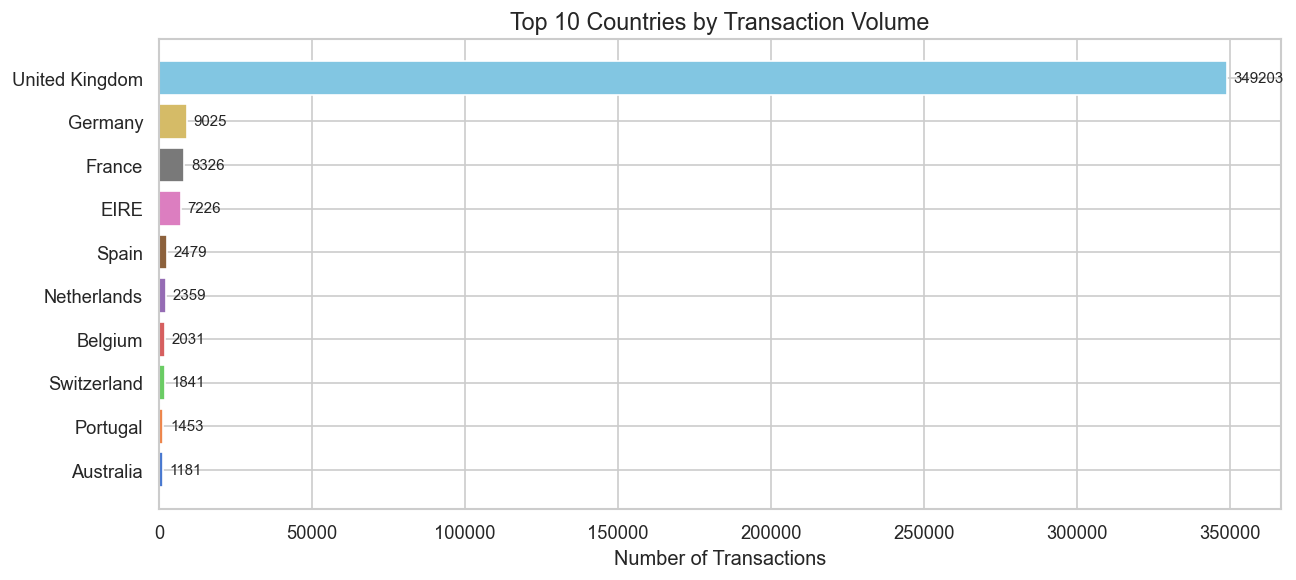

       Country  Transactions
United Kingdom        349203
       Germany          9025
        France          8326
          EIRE          7226
         Spain          2479
   Netherlands          2359
       Belgium          2031
   Switzerland          1841
      Portugal          1453
     Australia          1181


In [15]:
# Top 10 countries by number of transactions
country_counts = (df["Country"].value_counts()
                    .head(10)
                    .reset_index()
                    .rename(columns={"index":"Country","Country":"Transactions"}))
# pandas >=2 value_counts returns df with column name preserved
if "count" in country_counts.columns:
    country_counts.columns = ["Country","Transactions"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(country_counts["Country"][::-1],
               country_counts["Transactions"][::-1],
               color=sns.color_palette("muted", 10))
ax.set_xlabel("Number of Transactions")
ax.set_title("Top 10 Countries by Transaction Volume")
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
plt.tight_layout()
plt.savefig("eda_country_transactions.png", bbox_inches="tight")
plt.show()
print(country_counts.to_string(index=False))


### 3.2 Top-Selling Products (by Quantity)

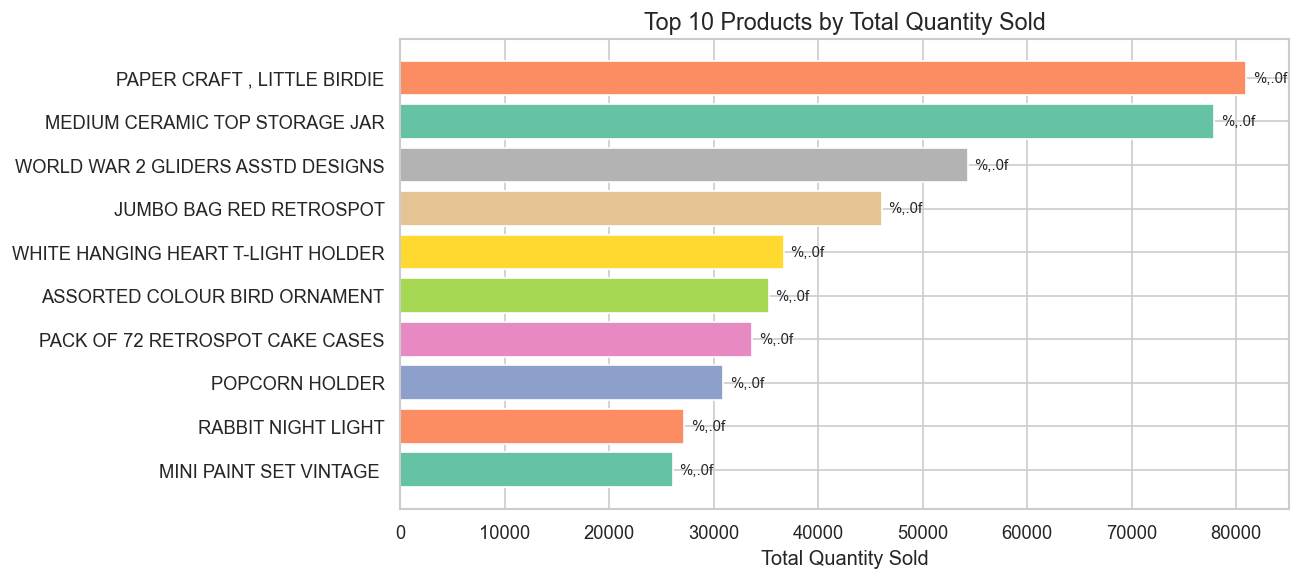

                       Description  Quantity
       PAPER CRAFT , LITTLE BIRDIE     80995
    MEDIUM CERAMIC TOP STORAGE JAR     77916
 WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
           JUMBO BAG RED RETROSPOT     46078
WHITE HANGING HEART T-LIGHT HOLDER     36706
     ASSORTED COLOUR BIRD ORNAMENT     35263
   PACK OF 72 RETROSPOT CAKE CASES     33670
                    POPCORN HOLDER     30919
                RABBIT NIGHT LIGHT     27153
           MINI PAINT SET VINTAGE      26076


In [16]:
top_products = (df.groupby("Description")["Quantity"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(10)
                     .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_products["Description"][::-1],
        top_products["Quantity"][::-1],
        color=sns.color_palette("Set2", 10))
ax.set_xlabel("Total Quantity Sold")
ax.set_title("Top 10 Products by Total Quantity Sold")
ax.bar_label(ax.containers[0], padding=4, fmt="%,.0f", fontsize=9)
plt.tight_layout()
plt.savefig("eda_top_products.png", bbox_inches="tight")
plt.show()
print(top_products.to_string(index=False))


### 3.3 Top Products by Revenue

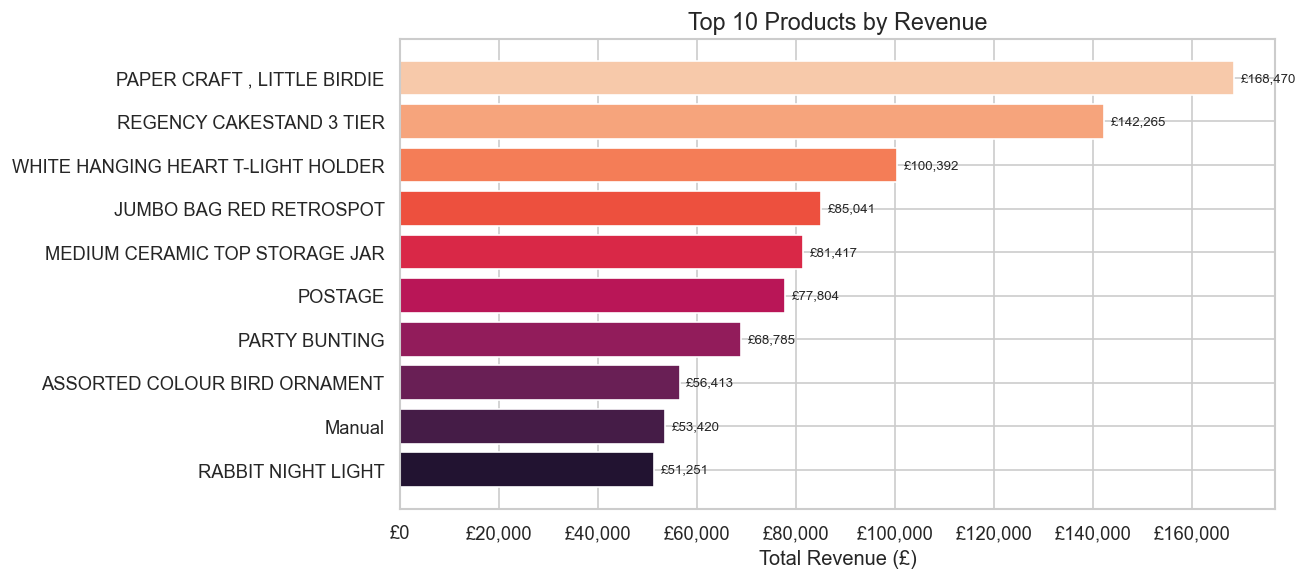

In [17]:
top_revenue = (df.groupby("Description")["TotalPrice"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(10)
                     .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_revenue["Description"][::-1],
        top_revenue["TotalPrice"][::-1],
        color=sns.color_palette("rocket", 10))
ax.set_xlabel("Total Revenue (£)")
ax.set_title("Top 10 Products by Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.bar_label(ax.containers[0], padding=4,
             labels=[f"£{v:,.0f}" for v in top_revenue["TotalPrice"][::-1]], fontsize=8)
plt.tight_layout()
plt.savefig("eda_top_revenue.png", bbox_inches="tight")
plt.show()


### 3.4 Purchase Trends Over Time

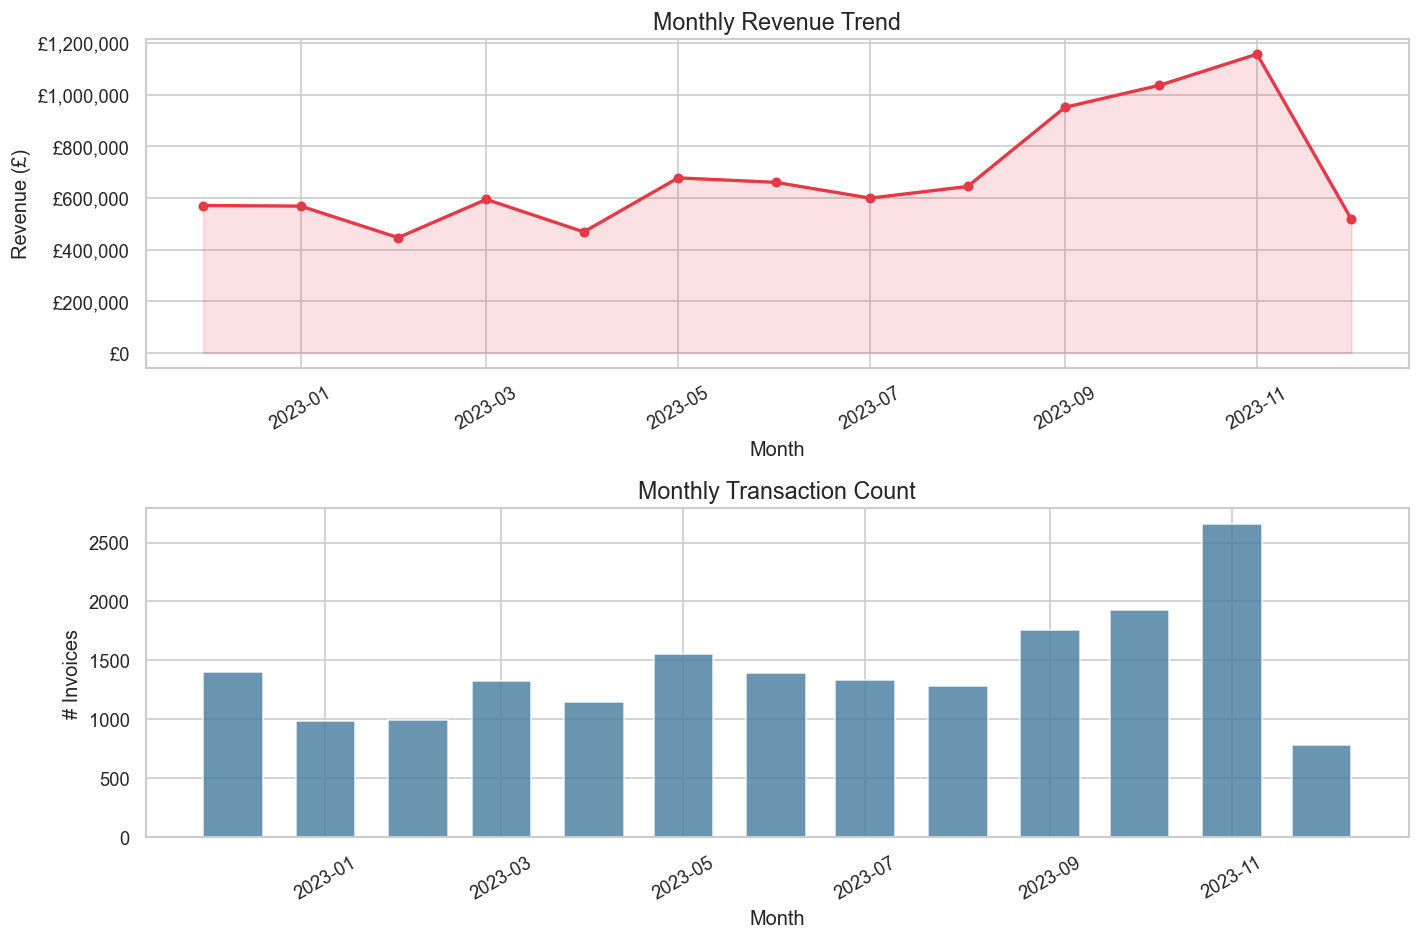

In [18]:
# Monthly revenue trend
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("YearMonth")["TotalPrice"].sum().reset_index()
monthly["YearMonth_dt"] = monthly["YearMonth"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Revenue
axes[0].plot(monthly["YearMonth_dt"], monthly["TotalPrice"],
             marker="o", color=PALETTE[0], linewidth=2, markersize=5)
axes[0].fill_between(monthly["YearMonth_dt"], monthly["TotalPrice"],
                     alpha=0.15, color=PALETTE[0])
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_ylabel("Revenue (£)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# Transaction count
monthly_tx = df.groupby("YearMonth")["InvoiceNo"].nunique().reset_index()
monthly_tx["YearMonth_dt"] = monthly_tx["YearMonth"].dt.to_timestamp()
axes[1].bar(monthly_tx["YearMonth_dt"], monthly_tx["InvoiceNo"],
            color=PALETTE[1], width=20, alpha=0.8)
axes[1].set_title("Monthly Transaction Count")
axes[1].set_ylabel("# Invoices")

for ax in axes:
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("eda_monthly_trends.png", bbox_inches="tight")
plt.show()


### 3.5 Purchase Patterns — Day of Week & Hour of Day

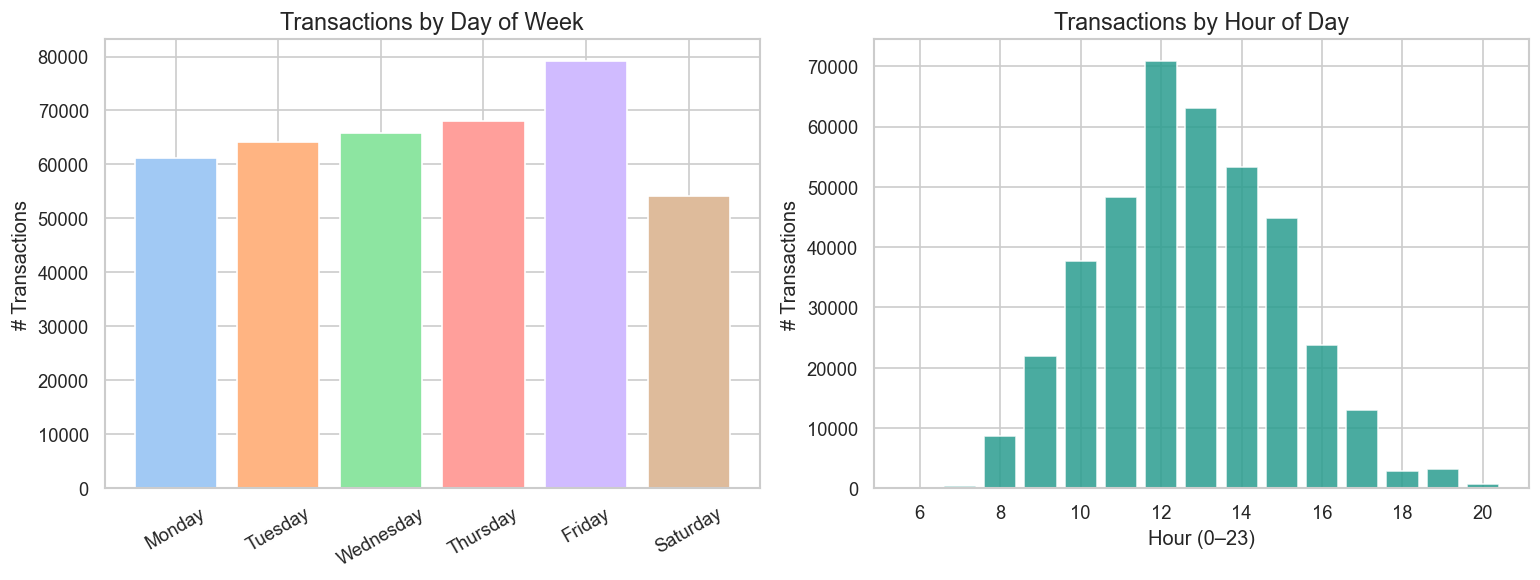

In [19]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"]      = df["InvoiceDate"].dt.hour

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df.groupby("DayOfWeek")["InvoiceNo"].count().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Day of week
axes[0].bar(day_counts.index, day_counts.values,
            color=sns.color_palette("pastel", 7))
axes[0].set_title("Transactions by Day of Week")
axes[0].set_ylabel("# Transactions")
axes[0].tick_params(axis="x", rotation=30)

# Hour of day
hour_counts = df.groupby("Hour")["InvoiceNo"].count()
axes[1].bar(hour_counts.index, hour_counts.values, color=PALETTE[2], alpha=0.85)
axes[1].set_title("Transactions by Hour of Day")
axes[1].set_xlabel("Hour (0–23)")
axes[1].set_ylabel("# Transactions")

plt.tight_layout()
plt.savefig("eda_time_patterns.png", bbox_inches="tight")
plt.show()


### 3.6 Monetary Distribution per Transaction & per Customer

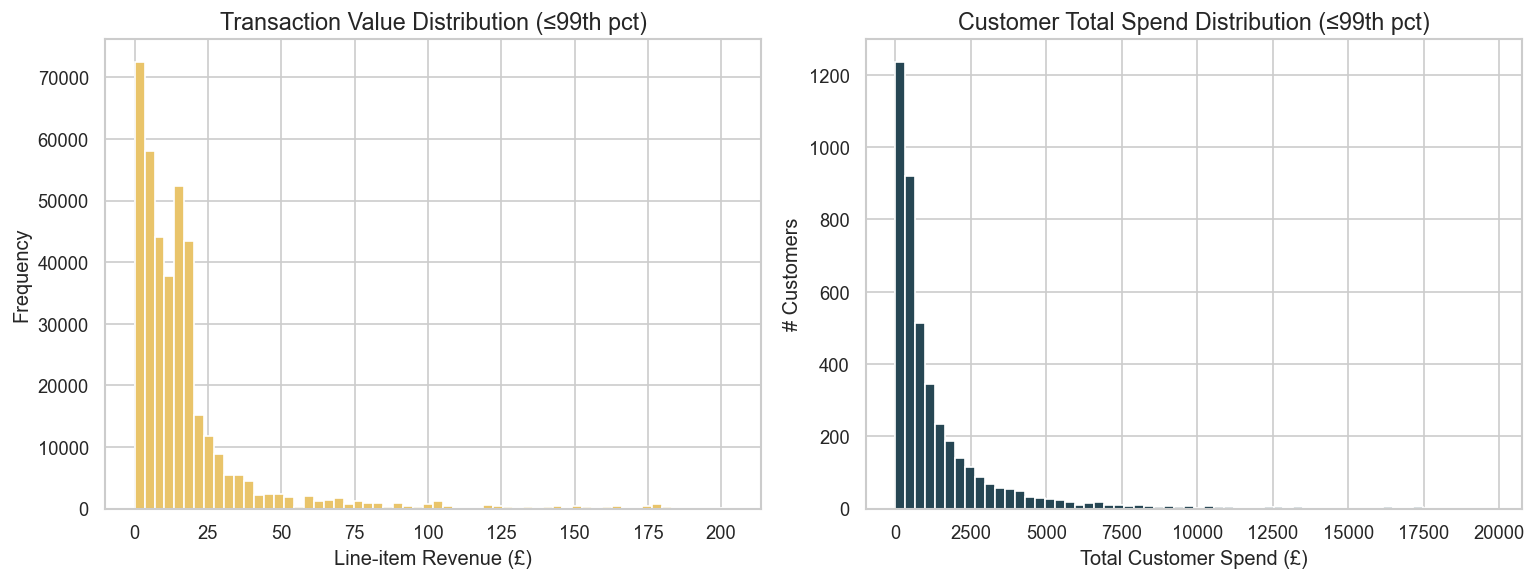

Transaction Value Stats:
count    £392,692.00
mean          £22.63
std          £311.10
min            £0.00
25%            £4.95
50%           £12.45
75%           £19.80
max      £168,469.60
Name: TotalPrice, dtype: object

Customer Total Spend Stats:
count      £4,338.00
mean       £2,048.69
std        £8,985.23
min            £3.75
25%          £306.48
50%          £668.57
75%        £1,660.60
max      £280,206.02
Name: TotalPrice, dtype: object


In [20]:
# Per transaction (capped at 99th percentile for readability)
tp_cap = df["TotalPrice"].quantile(0.99)
customer_total = df.groupby("CustomerID")["TotalPrice"].sum()
ct_cap = customer_total.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[df["TotalPrice"] <= tp_cap]["TotalPrice"],
             bins=60, color=PALETTE[3], edgecolor="white")
axes[0].set_title("Transaction Value Distribution (≤99th pct)")
axes[0].set_xlabel("Line-item Revenue (£)")
axes[0].set_ylabel("Frequency")

axes[1].hist(customer_total[customer_total <= ct_cap],
             bins=60, color=PALETTE[4], edgecolor="white")
axes[1].set_title("Customer Total Spend Distribution (≤99th pct)")
axes[1].set_xlabel("Total Customer Spend (£)")
axes[1].set_ylabel("# Customers")

plt.tight_layout()
plt.savefig("eda_monetary_dist.png", bbox_inches="tight")
plt.show()

print("Transaction Value Stats:")
print(df["TotalPrice"].describe().apply(lambda x: f"£{x:,.2f}"))
print()
print("Customer Total Spend Stats:")
print(customer_total.describe().apply(lambda x: f"£{x:,.2f}"))


---
## ⚙️ Step 4 — Feature Engineering: RFM Calculation


In [21]:
# ── Reference Date = 1 day after last transaction ─────────────
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency: {reference_date.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo",   "nunique"),
    Monetary  = ("TotalPrice",  "sum")
).reset_index()

print(f"\n✅ RFM Table Shape: {rfm.shape}")
rfm.head(10)


Reference Date for Recency: 2023-12-10

✅ RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [22]:
# ── RFM Summary Statistics ───────────────────────────────────
rfm.describe().round(2)


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


### 3.7 RFM Distributions

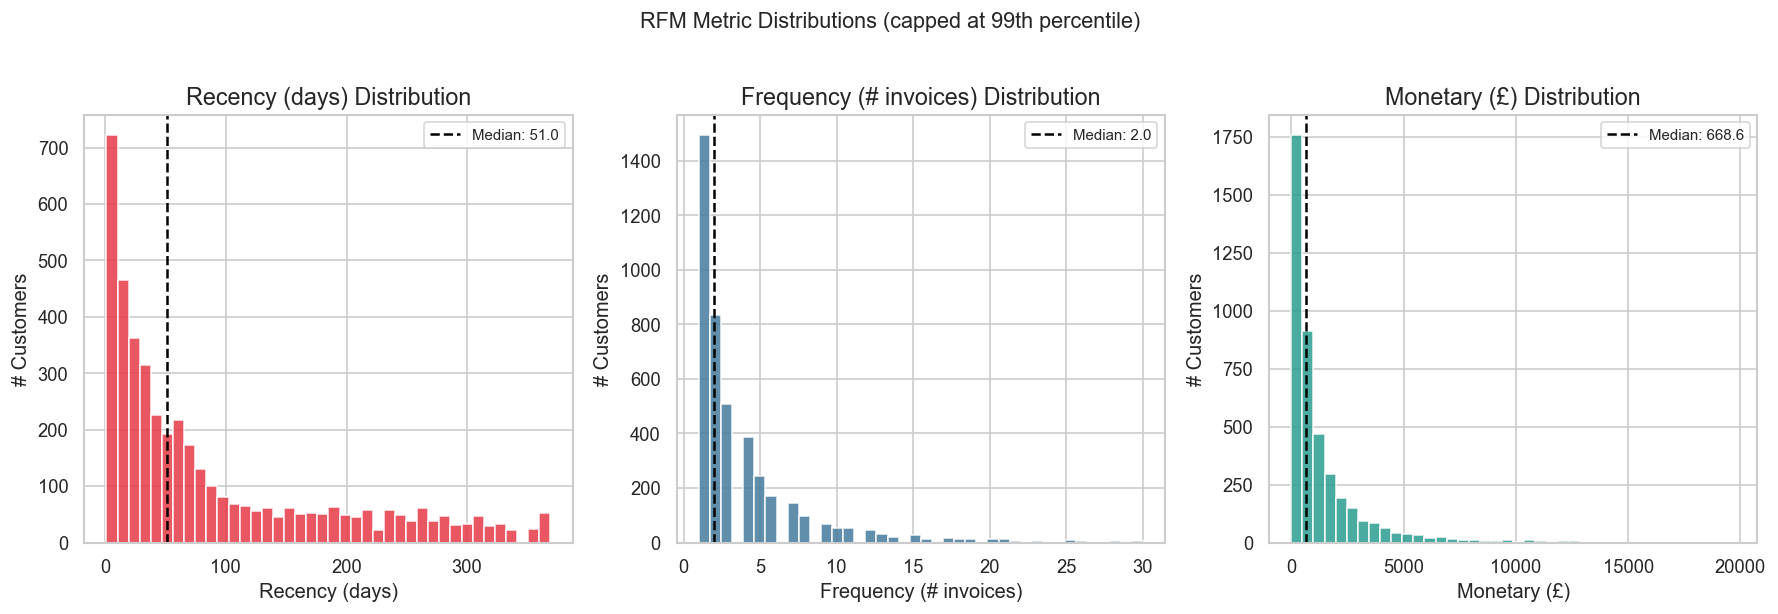

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = {
    "Recency (days)" : (rfm["Recency"],   PALETTE[0]),
    "Frequency (# invoices)": (rfm["Frequency"], PALETTE[1]),
    "Monetary (£)"  : (rfm["Monetary"],  PALETTE[2]),
}

for ax, (label, (series, color)) in zip(axes, metrics.items()):
    cap = series.quantile(0.99)
    ax.hist(series[series <= cap], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{label} Distribution")
    ax.set_xlabel(label)
    ax.set_ylabel("# Customers")
    ax.axvline(series.median(), color="black", linestyle="--",
               linewidth=1.5, label=f"Median: {series.median():.1f}")
    ax.legend(fontsize=9)

plt.suptitle("RFM Metric Distributions (capped at 99th percentile)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("eda_rfm_distributions.png", bbox_inches="tight")
plt.show()


### 3.8 RFM Correlation Heatmap

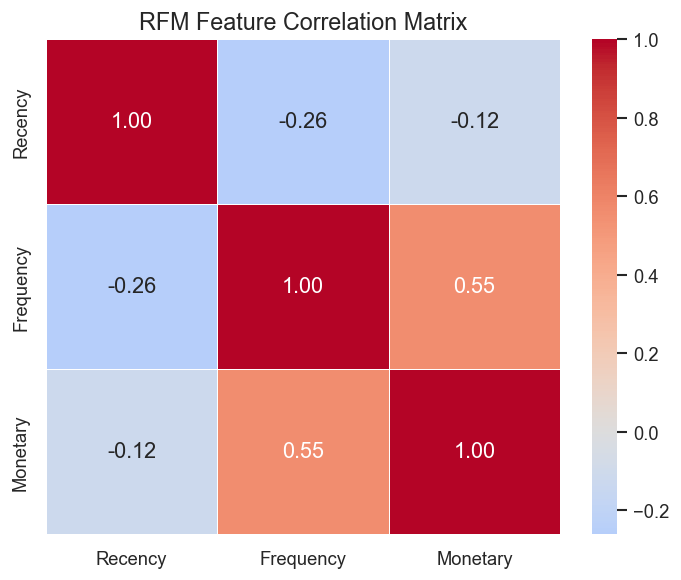

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = rfm[["Recency","Frequency","Monetary"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5,
            annot_kws={"size": 13})
ax.set_title("RFM Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("eda_rfm_correlation.png", bbox_inches="tight")
plt.show()


### 3.9 RFM Boxplots

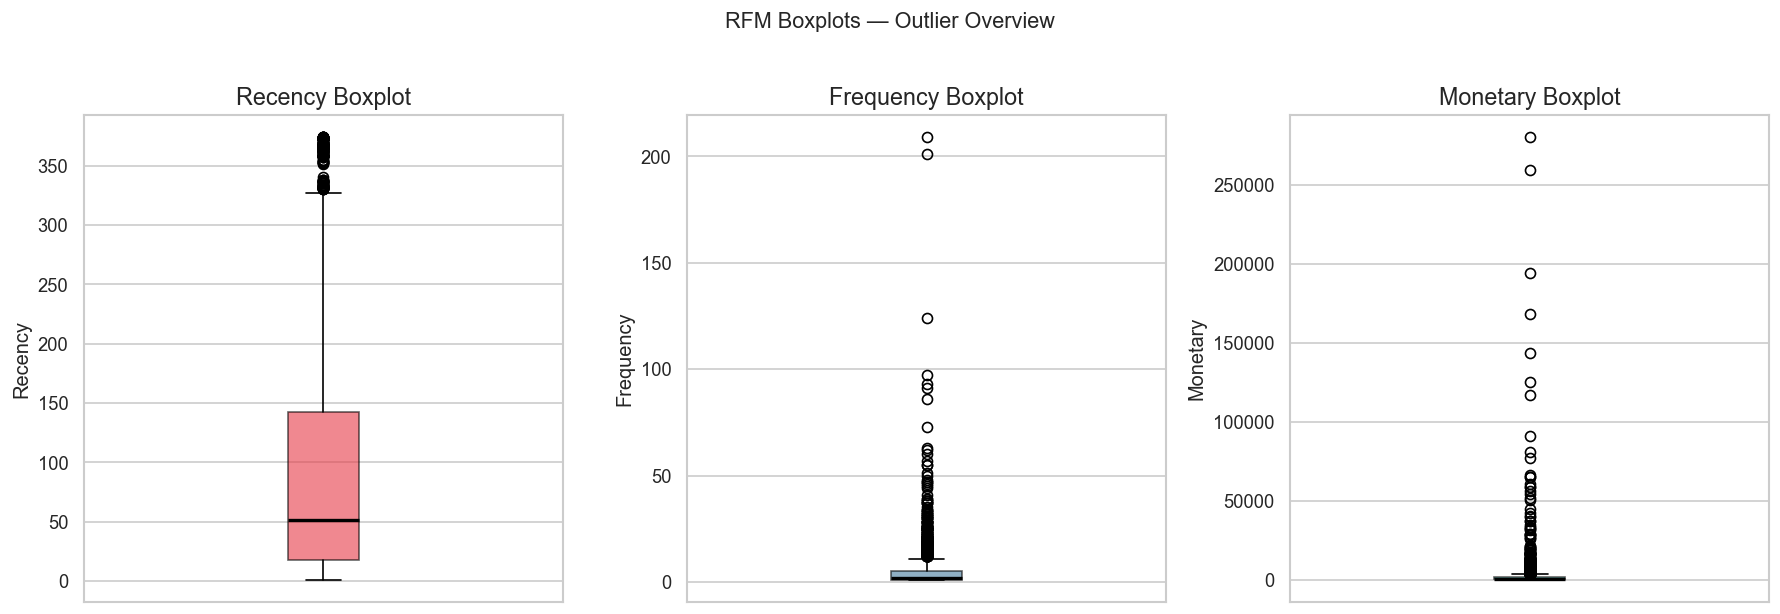

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rfm_cols = ["Recency", "Frequency", "Monetary"]
colors   = PALETTE[:3]

for ax, col, color in zip(axes, rfm_cols, colors):
    ax.boxplot(rfm[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2))
    ax.set_title(f"{col} Boxplot")
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.suptitle("RFM Boxplots — Outlier Overview", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("eda_rfm_boxplots.png", bbox_inches="tight")
plt.show()


### 3.10 Elbow Curve for K-Means Cluster Selection

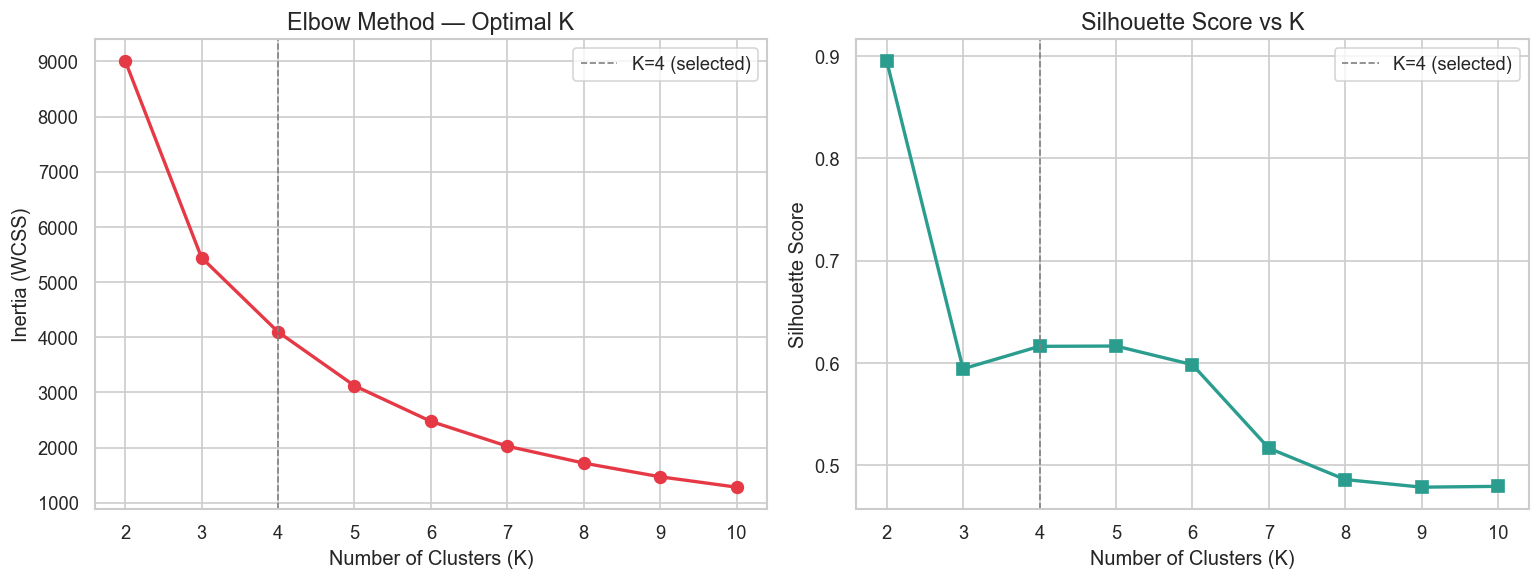

Best K by Silhouette Score : 2 (score=0.896)


In [26]:
# Normalise RFM before clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])

inertias      = []
sil_scores    = []
K_range       = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(K_range), inertias, "o-", color=PALETTE[0], linewidth=2, markersize=7)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method — Optimal K")
axes[0].axvline(4, color="gray", linestyle="--", linewidth=1, label="K=4 (selected)")
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), sil_scores, "s-", color=PALETTE[2], linewidth=2, markersize=7)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].axvline(4, color="gray", linestyle="--", linewidth=1, label="K=4 (selected)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best K by Silhouette Score : {best_k} (score={max(sil_scores):.3f})")


---
## ✅ EDA Summary

| Finding | Insight |
|---------|---------|
| **Top Country** | United Kingdom dominates transaction volume (~60%) |
| **Peak Trading** | Mid-week (Tue–Thu) and business hours (9 AM – 3 PM) |
| **Revenue Distribution** | Highly right-skewed; few customers drive disproportionate spend |
| **RFM Recency** | Most customers purchased recently, indicating active base |
| **RFM Frequency** | Majority are low-frequency buyers — 1–3 invoices |
| **RFM Monetary** | Long-tail distribution; a few high-value customers |
| **Optimal Clusters** | K=4 chosen based on Elbow + Silhouette analysis |

> **Next Steps:** Clustering (KMeans with K=4) → Segment labelling → Collaborative Filtering → Streamlit App


---
## 🤖 Step 5 — KMeans Clustering & Customer Segmentation


In [27]:
import pickle, os
os.makedirs("models", exist_ok=True)

# ── Standardize RFM ───────────────────────────────────────────
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])

# ── Fit KMeans with K=4 ───────────────────────────────────────
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(rfm_scaled)

print(f"Inertia        : {km.inertia_:.2f}")
print(f"Silhouette     : {silhouette_score(rfm_scaled, rfm['Cluster']):.3f}")
print()
print(rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(2))


Inertia        : 4096.30
Silhouette     : 0.616

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [28]:
# ── Assign Human-readable Segment Labels ─────────────────────
# Logic: lower Recency=more recent; higher F & M = more valuable
cluster_means = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

# Sort by Monetary descending to assign labels
sorted_by_monetary = cluster_means["Monetary"].sort_values(ascending=False).index.tolist()
label_order = ["High-Value", "Regular", "Occasional", "At-Risk"]

# Among high-monetary clusters, split At-Risk by Recency
# Manual mapping based on RFM profile:
#   High-Value  : Low Recency, High Freq, High Monetary
#   Regular     : Low-Med Recency, Med Freq, Med Monetary
#   Occasional  : Med Recency, Low Freq, Low Monetary
#   At-Risk     : High Recency (old), Low Freq, Low Monetary

recency_rank   = cluster_means["Recency"].rank()       # higher = older = worse
monetary_rank  = cluster_means["Monetary"].rank(ascending=False)  # higher = better
frequency_rank = cluster_means["Frequency"].rank(ascending=False)

score = monetary_rank + frequency_rank - recency_rank
score_sorted = score.sort_values(ascending=False).index.tolist()

LABEL_MAP = {score_sorted[0]: "High-Value",
             score_sorted[1]: "Regular",
             score_sorted[2]: "Occasional",
             score_sorted[3]: "At-Risk"}

rfm["Segment"] = rfm["Cluster"].map(LABEL_MAP)

print("Cluster → Segment Mapping:")
for c, s in LABEL_MAP.items():
    row = cluster_means.loc[c]
    print(f"  Cluster {c} → {s:12s} | R={row['Recency']:.0f}d  F={row['Frequency']:.1f}  M=£{row['Monetary']:.0f}")


Cluster → Segment Mapping:
  Cluster 1 → High-Value   | R=248d  F=1.6  M=£479
  Cluster 0 → Regular      | R=44d  F=3.7  M=£1354
  Cluster 3 → Occasional   | R=16d  F=22.3  M=£12691
  Cluster 2 → At-Risk      | R=7d  F=82.5  M=£127188


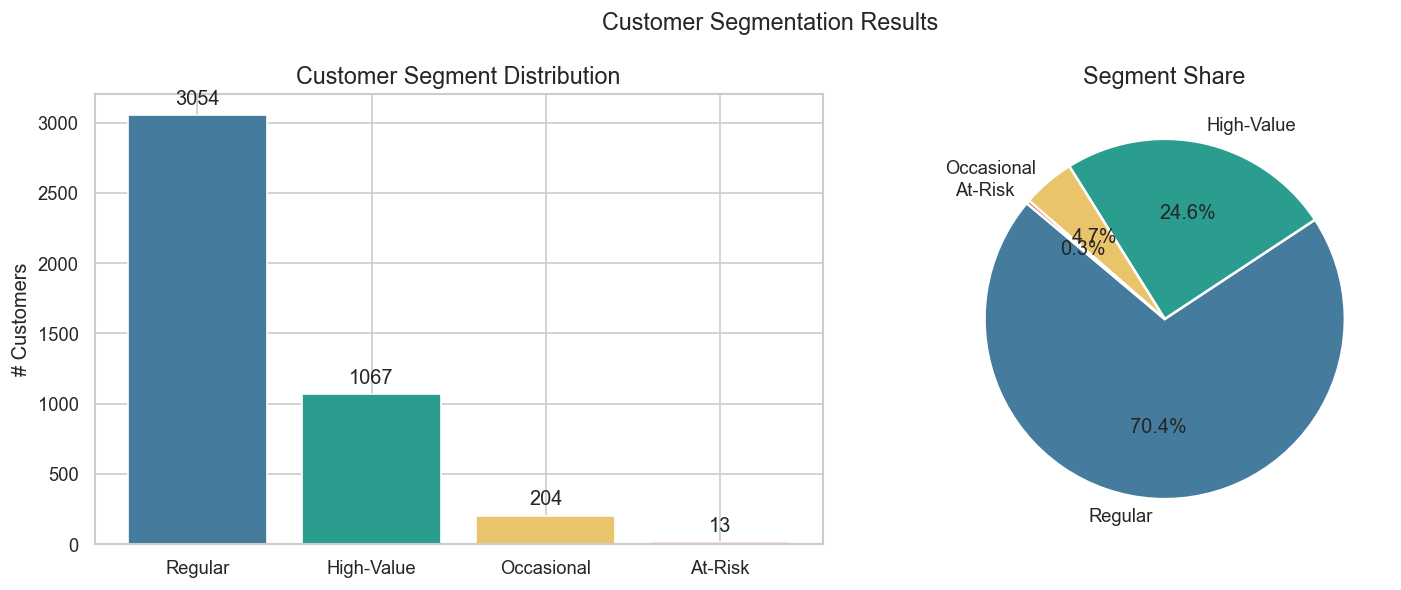

In [29]:
# ── Segment Distribution ─────────────────────────────────────
seg_counts = rfm["Segment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = {"High-Value": PALETTE[2], "Regular": PALETTE[1],
          "Occasional": PALETTE[3], "At-Risk": PALETTE[0]}
bar_colors = [colors[s] for s in seg_counts.index]
axes[0].bar(seg_counts.index, seg_counts.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Customer Segment Distribution")
axes[0].set_ylabel("# Customers")
axes[0].bar_label(axes[0].containers[0], padding=4)

# Pie chart
axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct="%1.1f%%", colors=bar_colors,
            startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Segment Share")

plt.suptitle("Customer Segmentation Results", fontsize=14)
plt.tight_layout()
plt.savefig("models/cluster_distribution.png", bbox_inches="tight")
plt.show()


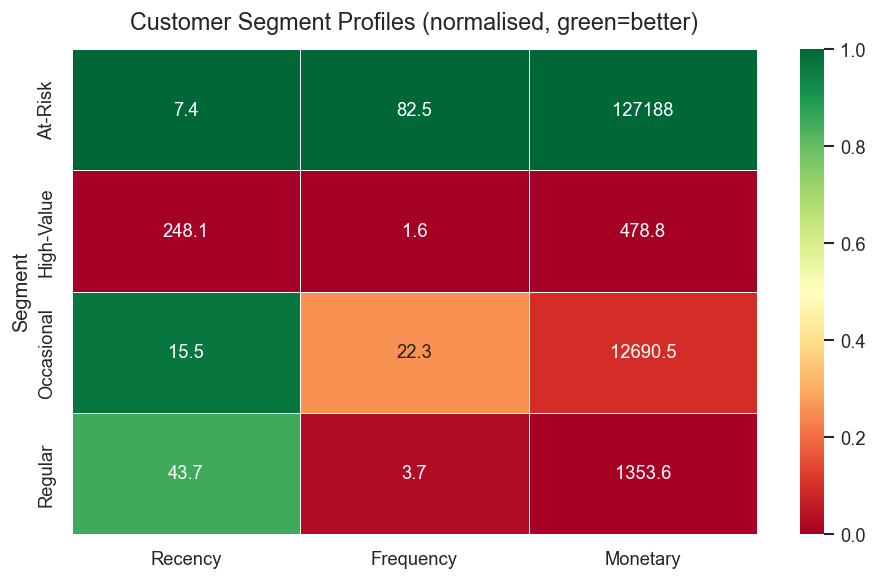

In [30]:
# ── Cluster Profile Heatmap ───────────────────────────────────
seg_profile = rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()
# Normalize each column 0-1 for heatmap readability
seg_norm = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())
# Invert Recency (lower=better)
seg_norm["Recency"] = 1 - seg_norm["Recency"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(seg_norm, annot=seg_profile.round(1), fmt="g",
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            annot_kws={"size": 11})
ax.set_title("Customer Segment Profiles (normalised, green=better)", pad=12)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("models/cluster_heatmap.png", bbox_inches="tight")
plt.show()


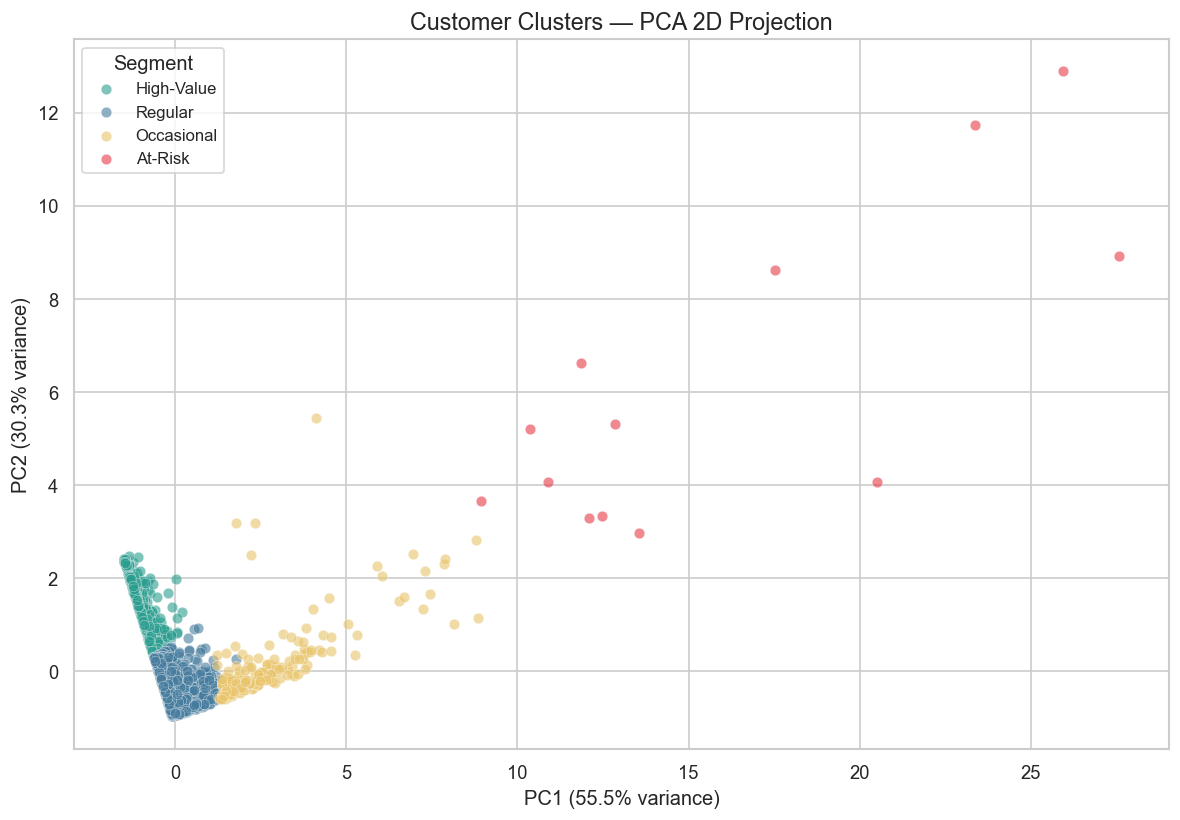

In [31]:
# ── 2D PCA Scatter Plot of Clusters ──────────────────────────
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for seg, color in colors.items():
    mask = rfm["Segment"] == seg
    ax.scatter(rfm.loc[mask, "PCA1"], rfm.loc[mask, "PCA2"],
               label=seg, color=color, alpha=0.6, s=40, edgecolors="white", linewidth=0.3)

ax.set_title("Customer Clusters — PCA 2D Projection", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(title="Segment", fontsize=10)
plt.tight_layout()
plt.savefig("models/cluster_pca_scatter.png", bbox_inches="tight")
plt.show()


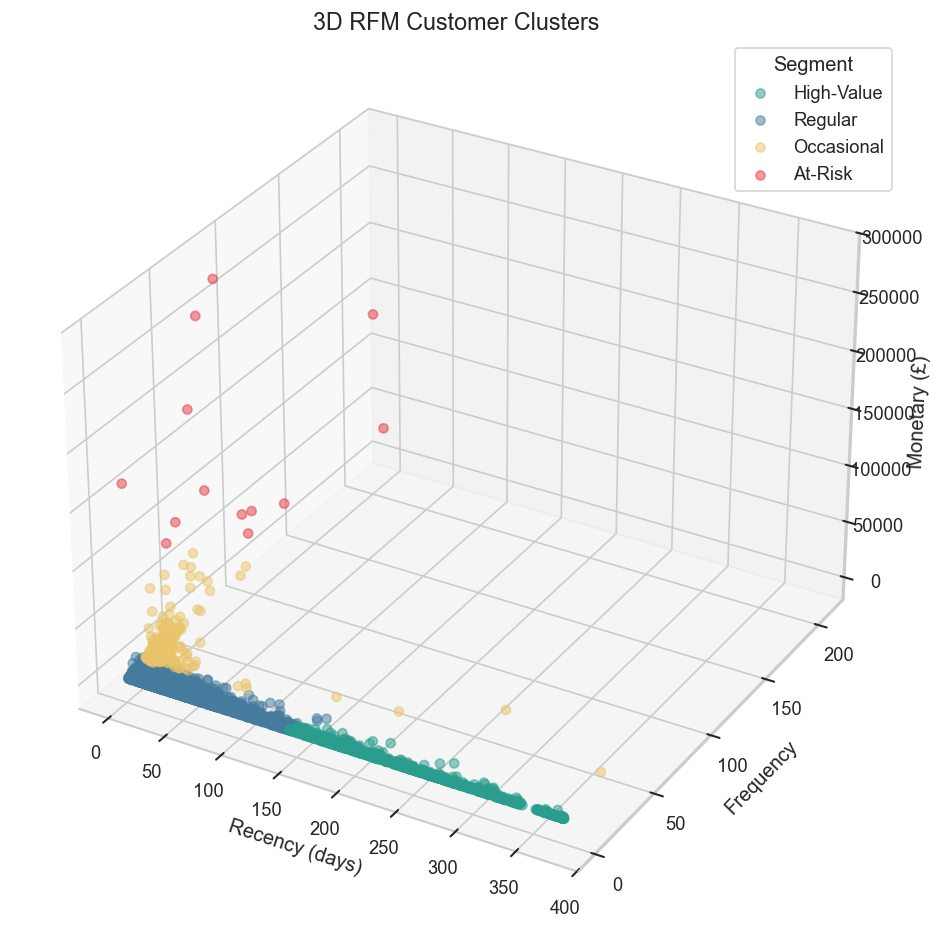

In [32]:
# ── 3D RFM Scatter ───────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

for seg, color in colors.items():
    mask = rfm["Segment"] == seg
    ax.scatter(rfm.loc[mask, "Recency"],
               rfm.loc[mask, "Frequency"],
               rfm.loc[mask, "Monetary"],
               label=seg, color=color, alpha=0.5, s=30)

ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary (£)")
ax.set_title("3D RFM Customer Clusters")
ax.legend(title="Segment")
plt.tight_layout()
plt.savefig("models/cluster_3d.png", bbox_inches="tight")
plt.show()


In [33]:
# ── Save Models ───────────────────────────────────────────────
pickle.dump(km,     open("models/kmeans_model.pkl", "wb"))
pickle.dump(scaler, open("models/scaler.pkl",       "wb"))
pickle.dump(LABEL_MAP, open("models/label_map.pkl", "wb"))
rfm.to_csv("models/rfm_clustered.csv", index=False)
print("✅ KMeans model, scaler, label_map and RFM CSV saved to /models/")


✅ KMeans model, scaler, label_map and RFM CSV saved to /models/


---
## 🎯 Step 6 — Product Recommendation System (Item-based Collaborative Filtering)


In [34]:
# ── Build Customer × Product Pivot Matrix ────────────────────
# Use top 100 products for memory efficiency
top_products = df["Description"].value_counts().head(100).index.tolist()
df_top = df[df["Description"].isin(top_products)].copy()

pivot = df_top.pivot_table(index="CustomerID", columns="Description",
                            values="Quantity", aggfunc="sum", fill_value=0)

print(f"Pivot matrix shape: {pivot.shape}  (customers × products)")
pivot.head(3)


Pivot matrix shape: (3968, 100)  (customers × products)


Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE RED,ANTIQUE SILVER T-LIGHT GLASS,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,CHARLOTTE BAG SUKI DESIGN,CHOCOLATE HOT WATER BOTTLE,...,SMALL WHITE HEART OF WICKER,SPACEBOY LUNCH BOX,SPOTTY BUNTING,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE SNAP CARDS,WHITE HANGING HEART T-LIGHT HOLDER,WOOD BLACK BOARD ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,WOODLAND CHARLOTTE BAG
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347.0,0,72,16,16,36,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,40
12348.0,0,144,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
# ── Compute Cosine Similarity Between Products ───────────────
sim_matrix = cosine_similarity(pivot.T)   # shape: products × products
sim_df = pd.DataFrame(sim_matrix,
                       index=pivot.columns,
                       columns=pivot.columns)

print(f"Similarity matrix shape: {sim_df.shape}")
sim_df.iloc[:4, :4].round(3)


Similarity matrix shape: (100, 100)


Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE PINK
Description,,,,
6 RIBBONS RUSTIC CHARM,1.000,0.203,0.034,0.053
60 TEATIME FAIRY CAKE CASES,0.203,1.000,0.022,0.051
ALARM CLOCK BAKELIKE GREEN,0.034,0.022,1.000,0.839
ALARM CLOCK BAKELIKE PINK,0.053,0.051,0.839,1.000


In [36]:
# ── Recommendation Function ───────────────────────────────────
def recommend_products(product_name: str, top_n: int = 5) -> list:
    """
    Given a product name, return top_n most similar products
    using cosine similarity on the customer-purchase matrix.
    """
    product_name = product_name.strip().upper()
    
    if product_name not in sim_df.index:
        # Fuzzy fallback: find closest match
        matches = [p for p in sim_df.index if product_name in p]
        if not matches:
            return [f"Product '{product_name}' not found in catalogue."]
        product_name = matches[0]
        print(f"  (Matched to: {product_name})")
    
    similar = (sim_df[product_name]
               .drop(product_name)          # exclude itself
               .sort_values(ascending=False)
               .head(top_n))
    return similar.index.tolist()

# ── Test ──────────────────────────────────────────────────────
test_product = "GREEN VINTAGE SPOT BEAKER"
recs = recommend_products(test_product)
print(f"\nProducts similar to: '{test_product}'")
for i, r in enumerate(recs, 1):
    print(f"  {i}. {r}")



Products similar to: 'GREEN VINTAGE SPOT BEAKER'
  1. Product 'GREEN VINTAGE SPOT BEAKER' not found in catalogue.


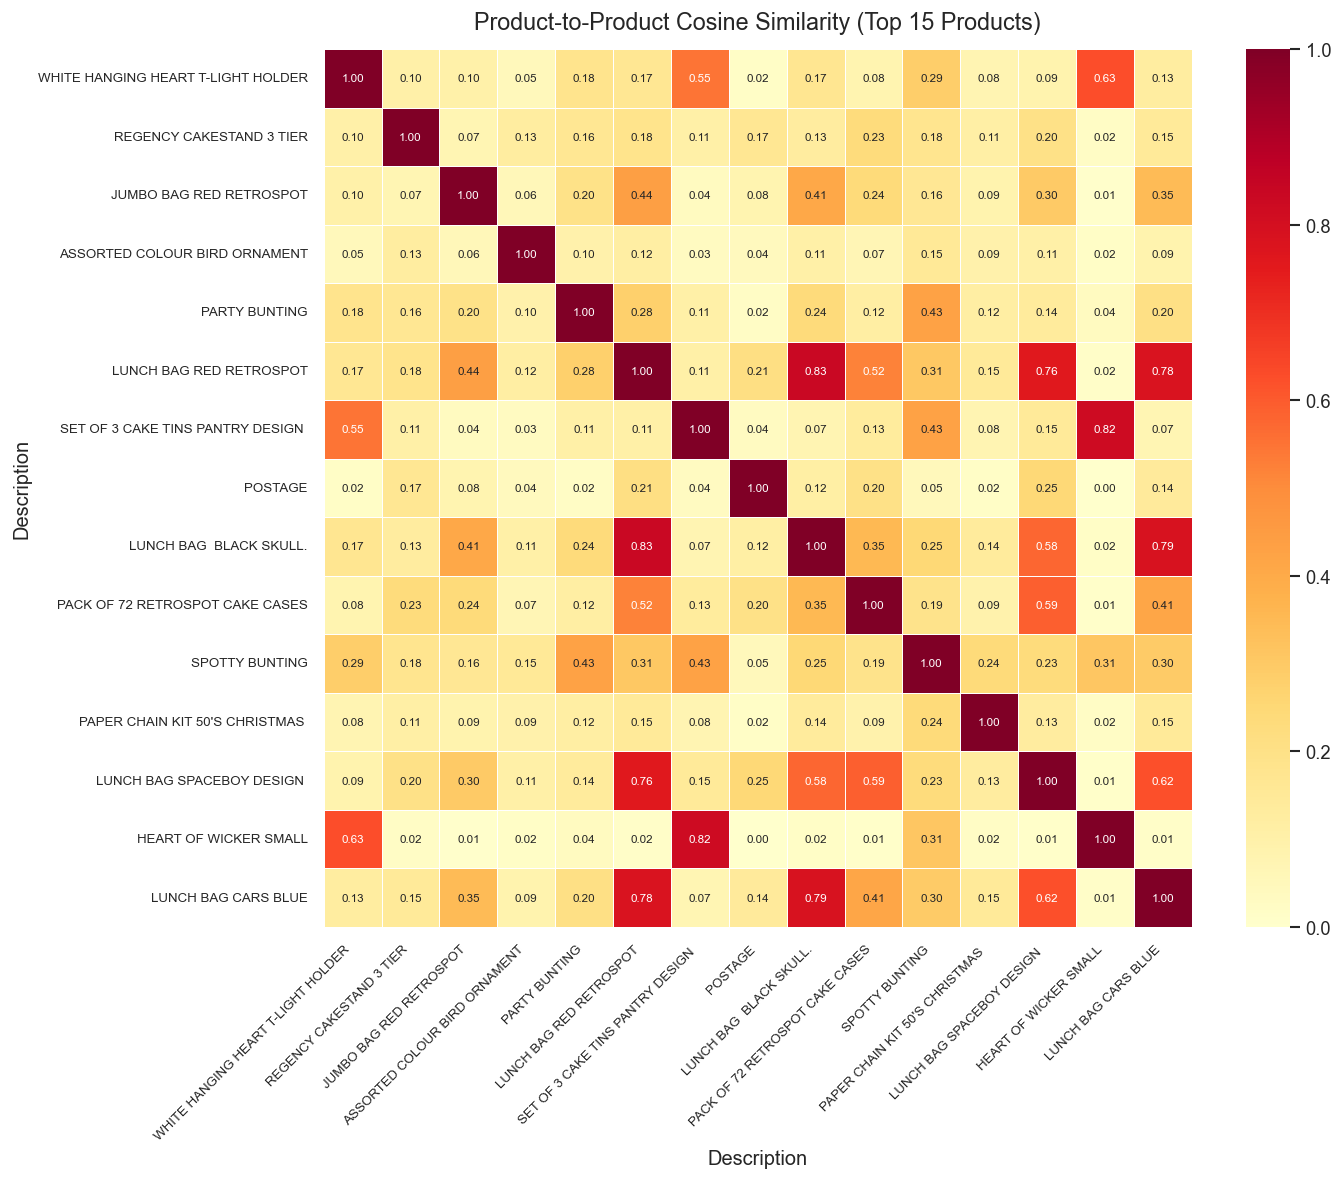

In [37]:
# ── Product Similarity Heatmap (top 15 products) ─────────────
top15 = df["Description"].value_counts().head(15).index.tolist()
sim_top15 = sim_df.loc[top15, top15]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_top15, cmap="YlOrRd", linewidths=0.3, ax=ax,
            xticklabels=True, yticklabels=True, vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7})
ax.set_title("Product-to-Product Cosine Similarity (Top 15 Products)", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("models/product_similarity_heatmap.png", bbox_inches="tight")
plt.show()


In [38]:
# ── Save Similarity Matrix & Product List ─────────────────────
sim_df.to_csv("models/product_similarity.csv")
with open("models/product_list.pkl", "wb") as f:
    pickle.dump(sim_df.index.tolist(), f)

print("✅ Similarity matrix and product list saved!")
print(f"   Total products in recommender: {len(sim_df)}")


✅ Similarity matrix and product list saved!
   Total products in recommender: 100


---
## ✅ Project Summary

| Module | Status | Key Output |
|--------|--------|------------|
| Data Preprocessing | ✅ Done | Clean df, TotalPrice column |
| EDA | ✅ Done | 10 visualizations |
| RFM Feature Engineering | ✅ Done | rfm DataFrame |
| KMeans Clustering (K=4) | ✅ Done | `models/kmeans_model.pkl` |
| Segment Labelling | ✅ Done | High-Value / Regular / Occasional / At-Risk |
| Collaborative Filtering | ✅ Done | `models/product_similarity.csv` |
| Streamlit App | ✅ Done | `app.py` |

> All model files are saved in the `models/` directory — ready for the Streamlit app.
